1. Tratamiento de valores faltantes que se obtuvieron despues de calcular los atributos con rezago. 
2. Despalzar hacia adelante a las variables con valores negativos. 
3. acampanar los atributos predictores y objetivo con boxcox. 
4. Escalar con probablemente con la téctica de estandarizado. 

In [1]:
import pandas as pd 

ubicacion_marco = r"C:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\2_recursos_ensenanza\5_arima\6_datos_arima\4_base_datos_consolidada\datos_semanal_meteo_epi_rezagos.xlsx"

df_semanal_meteo_epi_rezago = pd.read_excel(ubicacion_marco)

In [2]:
df_semanal_meteo_epi_rezago.head()

,año,semana_epi,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,...,sst_lag_7,sst_lag_8,sst_lag_9,sst_lag_10,sst_lag_11,sst_lag_12,sst_lag_13,sst_lag_14,sst_lag_15,sst_lag_16
0,2021,1,0,28.254286,34.200000,23.832857,16.367143,70.774286,7.73,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021,2,0,28.638571,34.910000,24.195714,17.318571,73.095714,19.18,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,3,1,29.552857,36.372857,24.090000,16.122857,65.328571,0.80,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,4,0,29.208571,35.978571,24.200000,16.564286,68.205714,12.81,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,5,0,29.421429,35.882857,24.684286,17.311429,69.797143,18.06,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_semanal_meteo_epi_rezago.isnull().sum()

La función `boxcox` de la librería `scipy.stats` es una herramienta fundamental en el análisis de datos para **estabilizar la varianza** y hacer que un conjunto de datos se aproxime más a una **distribución normal**.

Muchos modelos estadísticos (como la regresión lineal o el ANOVA) asumen que los residuos siguen una distribución normal. Si tus datos son "sesgados" o "ruidosos", la transformación de Box-Cox es tu mejor aliada.



## 1. ¿Qué hace exactamente?
Matemáticamente, la transformación está definida por un parámetro $\lambda$ (lambda). Para un dato $x$, la transformación $y$ se calcula de la siguiente manera:

$$y = \begin{cases} \frac{x^\lambda - 1}{\lambda} & \text{si } \lambda \neq 0 \\ \ln(x) & \text{si } \lambda = 0 \end{cases}$$

> **Condición crítica:** Box-Cox solo funciona con datos **estrictamente positivos** ($x > 0$). Si tienes valores de cero o negativos, deberás sumar una constante a tus datos antes de aplicarla.



---



## 2. Uso básico en Python
Para usarlo, necesitas importar la función y pasarle un array de datos.


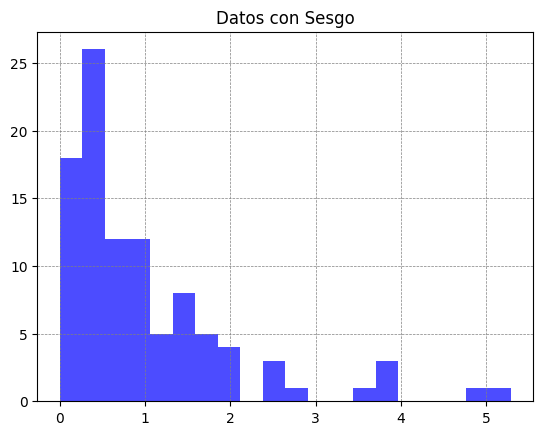

In [1]:
import matplotlib.pyplot as plt 
from scipy.stats import boxcox
import numpy as np

# Datos con sesgo (ejemplo: distribución exponencial)
datos = np.random.exponential(size=100)
plt.hist(datos, bins=20, color='blue', alpha=0.7)
plt.title('Datos con Sesgo')
plt.gca().set_facecolor('white')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()


El lambda óptimo es: 0.23530752121509838


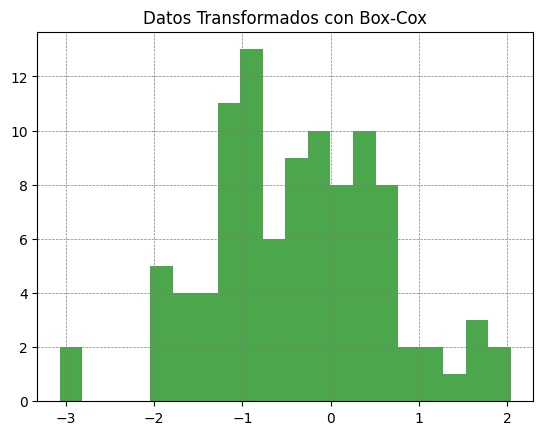

In [2]:

# Aplicar la transformación
datos_transformados, mejor_lambda = boxcox(datos)

print(f"El lambda óptimo es: {mejor_lambda}")
plt.hist(datos_transformados, bins=20, color='green', alpha=0.7)
plt.title('Datos Transformados con Box-Cox')
plt.gca().set_facecolor('white')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()


## Los dos valores de retorno:
1.  **`datos_transformados`**: El nuevo set de datos que ahora debería verse más "acampanado" (normalizado).
2.  **`mejor_lambda`**: El valor de $\lambda$ que SciPy calculó automáticamente para maximizar la normalidad de tus datos.

---

## 3. Interpretación de $\lambda$
El valor de lambda te dice qué tipo de transformación se aplicó "bajo el capó":

* **$\lambda = 1.0$**: No hay cambios (los datos ya eran normales).
* **$\lambda = 0.5$**: Transformación de raíz cuadrada.
* **$\lambda = 0.0$**: Transformación logarítmica natural ($\ln$).
* **$\lambda = -1.0$**: Transformación recíproca.

---

## 4. ¿Cuándo usarla?
* **Normalización:** Cuando quieres que tus datos sigan una campana de Gauss.
* **Homocedasticidad:** Cuando la variabilidad de tus datos no es constante y quieres "emparejarla".
* **Series Temporales:** Para eliminar variaciones estacionales que crecen proporcionalmente con el nivel de la serie.

### Una alternativa moderna
Si tus datos contienen ceros o valores negativos, en lugar de Box-Cox, se suele recomendar la **Transformación de Yeo-Johnson**, que también está disponible en `scipy.stats` (`yeojohnson`).

¿Estás trabajando con algún conjunto de datos específico que presente mucho sesgo o varianza inestable?